In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import scienceplots             # needed for 'science' style

# ensure inline rendering matches saved figure / uncomment for larger inline figures
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('pdf', 'svg')

DATA_DIR = Path("results")
FIG_DIR  = Path("figures")

# physical constants
GC_VAL_4X4 = 2.54
GC_VAL_3X3 = 2.22
GC_LABEL   = r"Critical Point $g_c$"
SUPPORT_LABEL_T = r"Support $g$"

# layout defaults
SINGLE_COL_WIDTH = 3.5
DOUBLE_COL_WIDTH = 7.16
DPI = 150       # dpi is irrelevant for our vectorized output files

# fixed z-order levels
Z_PATCH = -1  # background color
Z_BG    = 0   # support guides
Z_CRIT  = 1   # critical point line
Z_REF   = 2   # ED Reference lines
Z_DATA  = 3   # main data markers/lines

# global plot styling using scienceplots
plt.style.use(["science", "ieee"])
plt.rcParams.update({"mathtext.fontset": "cm", "text.usetex": False})

# hardcoded seaborn-colorblind palette
SB_COLORBLIND = [
    "#0173b2", "#de8f05", "#029e73", "#d55e00", "#cc78bc",
    "#ca9161", "#fbafe4", "#949494", "#ece133", "#56b4e9",
]

# shared styles across figures
STYLE_REF = {"linestyle": "--", "color": "black", "alpha": 0.7, "linewidth": 1.0}
STYLE_SUPP = { "linestyle": (0, (1.5, 2.8)), "linewidth": 0.75, "color": "0.20", "alpha": 0.30}
STYLE_CRIT = { "linestyle": ":", "linewidth": 1.1, "color": "indianred"}

# filter 'alpha' for legend handles so icons are opaque
STYLE_LEGEND = {k: v for k, v in STYLE_SUPP.items() if k != 'alpha'}

STYLE_MARKER_BASE = {
    "support": {"marker": "o", "edge_w": 0.0},
    "novel":   {"marker": "D", "edge_w": 1.2},
}

# vertical lines in the backdrop
def draw_backdrop(ax, support_values, crit_val):
    ax.patch.set_zorder(Z_PATCH)

    for g in sorted(support_values):
        ax.axvline(g, zorder=Z_BG, **STYLE_SUPP)

    ax.axvline(crit_val, zorder=Z_CRIT, **STYLE_CRIT)

In [2]:
CSV_PATH = DATA_DIR / "tfim_4x4_sample_eff_rbm_err_20260123_112349.csv"
wide = pd.read_csv(CSV_PATH)

overlap_cols = sorted(
    [c for c in wide.columns if c.startswith("overlap_") and not c.endswith("_err")],
    key=lambda c: int(c.split("_", 1)[1])
)

f1_data = []
f1_support_g = set()

for col in overlap_cols:
    n = int(col.split("_", 1)[1])
    err_col = f"{col}_err"   # matches overlap_2000 -> overlap_2000_err

    if err_col not in wide.columns:
        raise KeyError(f"Missing error column '{err_col}' for '{col}'")

    df = wide[["h", "type", col, err_col]].rename(
        columns={col: "overlap", err_col: "overlap_err"}
    ).copy()

    supp = df[df["type"] == "support"]
    nov  = df[df["type"] == "novel"]

    f1_support_g.update(supp["h"].values)
    f1_data.append({"n_samples": n, "df": df, "supp": supp, "nov": nov})

f1_support_g = sorted(f1_support_g)
print(f"Fig 1 data: {len(f1_data)} experiments loaded.")

Fig 1 data: 3 experiments loaded.


Saved: tfim_4x4_sample_eff_err.svg


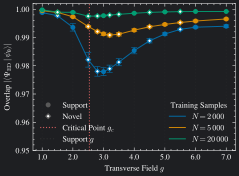

In [3]:
FIG_NAME = "tfim_4x4_sample_eff_err.svg"

# local styling overrides
SIZE_SUPP   = 5.0
SIZE_NOV    = 3.3
LEGEND_GREY = "0.35"
YLIM        = (0.95, 1.002)
LINE_ALPHA  = 0.9

# errorbar styling (vanilla knobs)
ERR_ELINEWIDTH = 0.7
ERR_CAPSIZE    = 3
ERR_CAPTHICK   = 0.7
ERR_ALPHA      = 0.85

# legend handles
h_sem_supp = Line2D([0], [0], linestyle="None", label="Support", marker=STYLE_MARKER_BASE["support"]["marker"],
                    markersize=SIZE_SUPP, markerfacecolor=LEGEND_GREY, markeredgecolor=LEGEND_GREY, markeredgewidth=0.0)

h_sem_nov  = Line2D([0], [0], linestyle="None", label="Novel", marker=STYLE_MARKER_BASE["novel"]["marker"],
                    markersize=SIZE_NOV, markerfacecolor="white", markeredgecolor=LEGEND_GREY,
                    markeredgewidth=STYLE_MARKER_BASE["novel"]["edge_w"])

h_sem_crit = Line2D([0], [0], label=GC_LABEL, **STYLE_CRIT)
h_sem_guide= Line2D([0], [0], label=SUPPORT_LABEL_T, alpha=1.0, **STYLE_LEGEND)

# figure plotting
width  = SINGLE_COL_WIDTH
height = width * 0.75
fig, ax = plt.subplots(figsize=(width, height), dpi=DPI)

for i, item in enumerate(f1_data):
    color = SB_COLORBLIND[i % len(SB_COLORBLIND)]
    n_tex = f"{item['n_samples']:,}".replace(",", r"\,")

    ax.plot(item["df"]["h"], item["df"]["overlap"], color=color, label=rf"$N={n_tex}$",
            linestyle="-", linewidth=1.0, alpha=LINE_ALPHA, zorder=Z_DATA)

    ax.errorbar(item["df"]["h"], item["df"]["overlap"], yerr=item["df"]["overlap_err"],
                fmt="None", ecolor=color, elinewidth=ERR_ELINEWIDTH, capsize=ERR_CAPSIZE,
                capthick=ERR_CAPTHICK, alpha=ERR_ALPHA, zorder=Z_DATA + 1, label="_nolegend_")

    ax.plot(item["supp"]["h"], item["supp"]["overlap"], linestyle="None", label="_nolegend_",
            marker=STYLE_MARKER_BASE["support"]["marker"], markersize=SIZE_SUPP,
            color=color, markerfacecolor=color, markeredgewidth=0.0, zorder=Z_DATA + 2)

    ax.plot(item["nov"]["h"], item["nov"]["overlap"], linestyle="None", label="_nolegend_",
            marker=STYLE_MARKER_BASE["novel"]["marker"], markersize=SIZE_NOV, color=color,
            markerfacecolor="white", markeredgewidth=STYLE_MARKER_BASE["novel"]["edge_w"], zorder=Z_DATA + 2)

draw_backdrop(ax, f1_support_g, GC_VAL_4X4)

ax.set_xlabel(r"Transverse Field $g$")
ax.set_ylabel(r"Overlap $\left|\left\langle \Psi_\mathrm{ED}\mid \psi_{\mathrm{θ}}\right\rangle\right|$")
if YLIM: ax.set_ylim(YLIM)

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.01))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

#ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

# robust legend creation to avoid handle loss. The second legend call detaches the first and we need to re-add it.
leg_samples = ax.legend(loc="lower right", title=r"Training Samples", frameon=False)
leg_semantic = ax.legend(handles=[h_sem_supp, h_sem_nov, h_sem_crit, h_sem_guide], loc="lower left", frameon=False)
ax.add_artist(leg_samples)

ax.grid(False)
fig.tight_layout()

if FIG_NAME:
    fig.savefig(FIG_DIR / FIG_NAME, bbox_inches="tight")
    print(f"Saved: {FIG_NAME}")
plt.show()

In [4]:
# -----------------
# combined susceptibility data loading
# -----------------

# 4x4 susceptibility
f4_susc_df = pd.read_csv(DATA_DIR / "tfim_4x4_suscept_rbm_err_20260122_232231.csv")
f4_ref_df = pd.read_csv(DATA_DIR / "tfim_4x4_suscept_ref.csv")

f4_h_eval = f4_susc_df["h"].values
f4_chi_val = f4_susc_df["chi_F"].values
f4_chi_err = f4_susc_df["chi_F_err"].values

f4_support_lines = [1.00, 1.10, 1.50, 2.00, 2.50, 3.00, 3.50, 4.00, 4.50]

# 3x3 susceptibility
f3_susc_df = pd.read_csv(DATA_DIR / "tfim_3x3_suscept_rbm_err_20260123_083111.csv")
f3_ref_df = pd.read_csv(DATA_DIR / "tfim_3x3_suscept_ref.csv")

f3_h_eval = f3_susc_df["h"].values
f3_chi_val = f3_susc_df["chi_F"].values
f3_chi_err = f3_susc_df["chi_F_err"].values

f3_support_lines = [1.00, 1.40, 1.50, 2.00, 2.50, 3.00, 3.50, 4.00, 4.50]

print("Combined susceptibility data loaded.")

Combined susceptibility data loaded.


Saved: tfim_4x4_3x3_suscept_err.svg


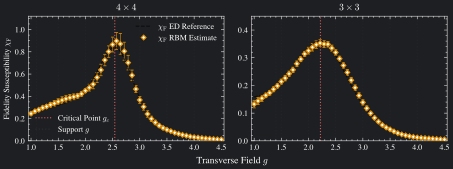

In [5]:
FIG_NAME = "tfim_4x4_3x3_suscept_err.svg"

# -----------------
# local settings
# -----------------
YLIM_4X4 = (0.0, 1.12)
YLIM_3X3 = (0.0, 0.45)
XLIM = (0.95, 4.55)

COLOR_MAIN = SB_COLORBLIND[1]
SIZE_NOV = 3.3

XLABEL_X = 0.52
XLABEL_Y = 0.11

ERR_ELINEWIDTH = 0.7
ERR_CAPSIZE = 1.6
ERR_CAPTHICK = 0.9
ERR_ALPHA = 0.85

FIG_MARGINS = {
    "left": 0.080, "right": 0.985,
    "bottom": 0.24, "top": 0.90,
    "wspace": 0.14
}

h_crit = Line2D([0], [0], label=GC_LABEL, **STYLE_CRIT)
h_guide = Line2D([0], [0], label=SUPPORT_LABEL_T, alpha=1.0, **STYLE_LEGEND)

h_ref = Line2D(
    [0], [0],
    label=r"$\chi_\mathrm{F}$ ED Reference",
    **STYLE_REF
)

h_rbm = Line2D(
    [0], [0],
    linestyle="None",
    label=r"$\chi_\mathrm{F}$ RBM Estimate",
    marker=STYLE_MARKER_BASE["novel"]["marker"],
    markersize=SIZE_NOV,
    color=COLOR_MAIN,
    markerfacecolor="white",
    markeredgewidth=STYLE_MARKER_BASE["novel"]["edge_w"],
)


# -----------------
# plotting helper
# -----------------
def _plot_suscept_panel(ax, h_eval, chi_val, chi_err, ref_df, support_lines, crit_val, ylim):
    ax.patch.set_zorder(Z_PATCH)

    ax.errorbar(
        h_eval, chi_val, yerr=chi_err, fmt="None",
        ecolor=COLOR_MAIN,
        elinewidth=ERR_ELINEWIDTH,
        capsize=ERR_CAPSIZE,
        capthick=ERR_CAPTHICK,
        alpha=ERR_ALPHA,
        zorder=Z_REF - 2,
        label="_nolegend_"
    )

    ax.plot(
        ref_df["h"].values,
        ref_df["chi_F"].values,
        zorder=Z_REF,
        label=r"$\chi_\mathrm{F}$ ED Reference",
        **STYLE_REF
    )

    ax.plot(
        h_eval,
        chi_val,
        linestyle="None",
        label=r"$\chi_\mathrm{F}$ RBM Estimate",
        marker=STYLE_MARKER_BASE["novel"]["marker"],
        markersize=SIZE_NOV,
        color=COLOR_MAIN,
        markerfacecolor="white",
        markeredgewidth=STYLE_MARKER_BASE["novel"]["edge_w"],
        zorder=Z_REF + 1
    )

    draw_backdrop(ax, support_lines, crit_val)

    ax.set_xlim(XLIM)
    ax.set_ylim(ylim)
    ax.grid(False)


# -----------------
# actual plotting
# -----------------
panel_width = SINGLE_COL_WIDTH * 0.92
panel_height = SINGLE_COL_WIDTH * 0.75

width = 2 * panel_width
height = panel_height

fig, axes = plt.subplots(
    1, 2,
    figsize=(width, height),
    dpi=DPI,
    sharex=True,
    sharey=False,
    gridspec_kw={"wspace": 0.14},
    constrained_layout=False
)

_plot_suscept_panel(
    axes[0],
    f4_h_eval,
    f4_chi_val,
    f4_chi_err,
    f4_ref_df,
    f4_support_lines,
    GC_VAL_4X4,
    YLIM_4X4
)

_plot_suscept_panel(
    axes[1],
    f3_h_eval,
    f3_chi_val,
    f3_chi_err,
    f3_ref_df,
    f3_support_lines,
    GC_VAL_3X3,
    YLIM_3X3
)

axes[0].set_title(r"$4\times4$")
axes[1].set_title(r"$3\times3$")

axes[0].set_ylabel(r"Fidelity Susceptibility $\chi_\mathrm{F}$")
fig.supxlabel(r"Transverse Field $g$", x=XLABEL_X, y=XLABEL_Y)

for ax in axes:
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

leg_main = axes[0].legend(
    handles=[h_ref, h_rbm],
    loc="upper right",
    frameon=False
)

leg_guides = axes[0].legend(
    handles=[h_crit, h_guide],
    loc="lower left",
    frameon=False
)

axes[0].add_artist(leg_main)

fig.subplots_adjust(**FIG_MARGINS)
fig.set_size_inches(width, height, forward=True)

if FIG_NAME:
    fig.savefig(FIG_DIR / FIG_NAME)
    print(f"Saved: {FIG_NAME}")

plt.show()

In [6]:
SIDE_LENGTH = 4
base = f"tfim_{SIDE_LENGTH}x{SIDE_LENGTH}_magnet"

one_df = pd.read_csv(DATA_DIR / f"{base}_one_rbm_err_20260123_110439.csv")
two_df = pd.read_csv(DATA_DIR / f"{base}_two_rbm_err_20260123_110526.csv")
many_df = pd.read_csv(DATA_DIR / f"{base}_many_rbm_err_20260123_110536.csv")
ref_df = pd.read_csv(DATA_DIR / f"{base}_ref.csv")

print("Fig 4 data loaded.")

Fig 4 data loaded.


Saved: tfim_4x4_magnet_err.svg


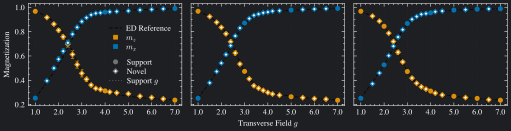

In [7]:
FIG_NAME = f"tfim_{SIDE_LENGTH}x{SIDE_LENGTH}_magnet_err.svg"

# -----------------
# local settings
# -----------------
SIZE_SUPP   = 5.1
SIZE_NOV    = 3.2
SIZE_OBS    = 3.7
LEGEND_GREY = "0.45"

COLOR_Z = SB_COLORBLIND[1]
COLOR_X = SB_COLORBLIND[0]

FIG_MARGINS = {
    "left": 0.055, "right": 0.985,
    "bottom": 0.30, "top": 0.92,
    "wspace": 0.06
}

# legend placement in first panel
LEGEND_OBS_ANCHOR = (0.95, 0.82)   # upper-right legend
LEGEND_SEM_ANCHOR = (0.865, 0.17)   # lower-right legend

# errorbar styling
ERR_ELINEWIDTH = 0.7
ERR_CAPSIZE    = 1.6
ERR_CAPTHICK   = 0.9
ERR_ALPHA      = 0.85

# slightly lighter support-guide handle than the plotted guide lines
STYLE_LEGEND_LIGHT = {**STYLE_LEGEND, "color": "0.45", "linewidth": 0.70}


# -----------------
# legend handles
# -----------------
h_obs_z = Line2D(
    [0], [0], linestyle="None",
    marker="s", markersize=SIZE_OBS,
    markerfacecolor=COLOR_Z, markeredgecolor=COLOR_Z,
    label=r"$m_z$"
)

h_obs_x = Line2D(
    [0], [0], linestyle="None",
    marker="s", markersize=SIZE_OBS,
    markerfacecolor=COLOR_X, markeredgecolor=COLOR_X,
    label=r"$m_x$"
)

h_sem_supp = Line2D(
    [0], [0], linestyle="None",
    marker=STYLE_MARKER_BASE["support"]["marker"],
    markersize=SIZE_SUPP,
    markerfacecolor=LEGEND_GREY,
    markeredgecolor=LEGEND_GREY,
    markeredgewidth=0.0,
    label="Support"
)

h_sem_nov = Line2D(
    [0], [0], linestyle="None",
    marker=STYLE_MARKER_BASE["novel"]["marker"],
    markersize=SIZE_NOV,
    markerfacecolor="white",
    markeredgecolor=LEGEND_GREY,
    markeredgewidth=STYLE_MARKER_BASE["novel"]["edge_w"],
    label="Novel"
)

h_ref = Line2D([0], [0], label="ED Reference", **STYLE_REF)
h_guide = Line2D([0], [0], label=SUPPORT_LABEL_T, alpha=1.0, **STYLE_LEGEND_LIGHT)


# -----------------
# plotting helper
# -----------------
def _plot_panel(ax, df, ref_df):
    if df is None:
        return

    ax.patch.set_zorder(Z_PATCH)

    support_g = np.unique(df[df["type"] == "support"]["h"].to_numpy())
    for g0 in support_g:
        ax.axvline(g0, zorder=Z_BG, **STYLE_SUPP)

    ax.plot(ref_df["h"], ref_df["mag_z"], zorder=Z_REF, **STYLE_REF)
    ax.plot(ref_df["h"], ref_df["mag_x"], zorder=Z_REF, **STYLE_REF)

    for type_key, sub_df in df.groupby("type"):
        if type_key not in ["support", "novel"]:
            continue

        sz   = SIZE_SUPP if type_key == "support" else SIZE_NOV
        base = STYLE_MARKER_BASE[type_key]

        fc_z = COLOR_Z if type_key == "support" else "white"
        fc_x = COLOR_X if type_key == "support" else "white"

        ax.errorbar(
            sub_df["h"], sub_df["mag_z"], yerr=sub_df["mag_z_err"],
            fmt="None", ecolor=COLOR_Z,
            elinewidth=ERR_ELINEWIDTH, capsize=ERR_CAPSIZE,
            capthick=ERR_CAPTHICK, alpha=ERR_ALPHA,
            zorder=Z_REF - 2, label="_nolegend_"
        )

        ax.errorbar(
            sub_df["h"], sub_df["mag_x"], yerr=sub_df["mag_x_err"],
            fmt="None", ecolor=COLOR_X,
            elinewidth=ERR_ELINEWIDTH, capsize=ERR_CAPSIZE,
            capthick=ERR_CAPTHICK, alpha=ERR_ALPHA,
            zorder=Z_REF - 2, label="_nolegend_"
        )

        ax.plot(
            sub_df["h"], sub_df["mag_z"], linestyle="None",
            color=COLOR_Z, zorder=Z_REF + 1,
            marker=base["marker"], markersize=sz,
            markerfacecolor=fc_z, markeredgewidth=base["edge_w"]
        )

        ax.plot(
            sub_df["h"], sub_df["mag_x"], linestyle="None",
            color=COLOR_X, zorder=Z_REF + 1,
            marker=base["marker"], markersize=sz,
            markerfacecolor=fc_x, markeredgewidth=base["edge_w"]
        )


# -----------------
# actual plotting
# -----------------
width  = DOUBLE_COL_WIDTH
height = width * 0.32

fig, axes = plt.subplots(
    1, 3,
    figsize=(width, height),
    dpi=DPI,
    sharey=True,
    gridspec_kw={"wspace": 0.06},
    constrained_layout=False
)

_plot_panel(axes[0], one_df,  ref_df)
_plot_panel(axes[1], two_df,  ref_df)
_plot_panel(axes[2], many_df, ref_df)

axes[0].set_ylabel("Magnetization")
axes[1].set_xlabel(r"Transverse Field $g$")

for ax in axes:
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.grid(False)

# upper-right legend in first panel: ED reference + observable colors
leg_obs = axes[0].legend(
    handles=[h_ref, h_obs_z, h_obs_x],
    loc="upper right",
    bbox_to_anchor=LEGEND_OBS_ANCHOR,
    frameon=False,
    handlelength=1.6,
    handletextpad=0.5,
    labelspacing=0.25,
    borderaxespad=0.0
)

# lower-right legend in first panel: support / novel / support g
leg_sem = axes[0].legend(
    handles=[h_sem_supp, h_sem_nov, h_guide],
    loc="lower right",
    bbox_to_anchor=LEGEND_SEM_ANCHOR,
    frameon=False,
    handlelength=1.6,
    handletextpad=0.6,
    labelspacing=0.25,
    borderaxespad=0.0
)

axes[0].add_artist(leg_obs)

# manual margins for precise PDF sizing
fig.subplots_adjust(**FIG_MARGINS)
fig.set_size_inches(width, height, forward=True)

if FIG_NAME:
    fig.savefig(FIG_DIR / FIG_NAME)
    print(f"Saved: {FIG_NAME}")

plt.show()

In [8]:
SIDE_LENGTH = 4
G_SAMPLE = 1.00
N_SAMPLES = 2_000
MODEL_KINDS = ["vanilla", "symm"]


def latest_file(pattern: str, directory: Path = DATA_DIR) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f"No files found for pattern: {pattern}")
    return files[-1]


imbalance_data = {}

for model_kind in MODEL_KINDS:
    overlap_path = latest_file(
        f"tfim_{SIDE_LENGTH}x{SIDE_LENGTH}_imbalance_overlap_{model_kind}_*.csv"
    )
    counts_path = latest_file(
        f"tfim_{SIDE_LENGTH}x{SIDE_LENGTH}_imbalance_counts_g{G_SAMPLE:.2f}_{model_kind}_*.csv"
    )

    overlap_df = pd.read_csv(overlap_path)
    counts_df = pd.read_csv(counts_path)

    support_df = (
        overlap_df[overlap_df["type"] == "support"]
        .copy()
        .sort_values("h")
    )

    imbalance_data[model_kind] = {
        "support_df": support_df,
        "counts_df": counts_df,
        "support_g": sorted(support_df["h"].unique()),
        "overlap_path": overlap_path,
        "counts_path": counts_path,
    }

    print(f"[{model_kind}] overlap: {overlap_path.name}")
    print(f"[{model_kind}] counts : {counts_path.name}")

[vanilla] overlap: tfim_4x4_imbalance_overlap_vanilla_20260604_172602.csv
[vanilla] counts : tfim_4x4_imbalance_counts_g1.00_vanilla_20260604_172617.csv
[symm] overlap: tfim_4x4_imbalance_overlap_symm_20260604_174304.csv
[symm] counts : tfim_4x4_imbalance_counts_g1.00_symm_20260604_174645.csv


Saved: tfim_4x4_imbalance_overlap_compare.svg


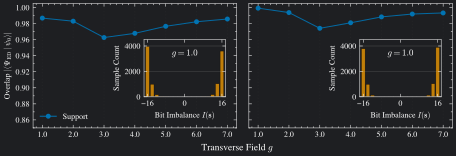

In [12]:
FIG_NAME = f"tfim_{SIDE_LENGTH}x{SIDE_LENGTH}_imbalance_overlap_compare.svg"

COLOR_MAIN = SB_COLORBLIND[0]
COLOR_INSET = SB_COLORBLIND[1]

SIZE_SUPP = 5.0
LINE_ALPHA = 0.9
YLIM = (0.85, 1.005)

PANEL_WSPACE = 0.06

ERR_ELINEWIDTH = 0.7
ERR_CAPSIZE = 3
ERR_CAPTHICK = 0.7
ERR_ALPHA = 0.85

FIG_MARGINS = {
    "left": 0.080,
    "right": 0.985,
    "bottom": 0.24,
    "top": 0.90,
    "wspace": PANEL_WSPACE,
}

INSET_BOUNDS = [0.545, 0.25, 0.40, 0.46]

panel_width = SINGLE_COL_WIDTH * 0.92
panel_height = SINGLE_COL_WIDTH * 0.75
width = 2 * panel_width
height = panel_height

h_support = Line2D(
    [0], [0],
    linestyle="-",
    linewidth=1.0,
    color=COLOR_MAIN,
    marker=STYLE_MARKER_BASE["support"]["marker"],
    markersize=SIZE_SUPP,
    markerfacecolor=COLOR_MAIN,
    markeredgecolor=COLOR_MAIN,
    markeredgewidth=0.0,
    label="Support"
)


def draw_support_only_backdrop(ax, support_values):
    ax.patch.set_zorder(Z_PATCH)
    for g in sorted(support_values):
        ax.axvline(g, zorder=Z_BG, **STYLE_SUPP)


def _plot_imbalance_panel(ax, item, add_legend=False):
    support_df = item["support_df"]
    counts_df = item["counts_df"]
    support_g = item["support_g"]

    col = f"overlap_{N_SAMPLES}"
    err_col = f"{col}_err"

    ax.plot(
        support_df["h"], support_df[col],
        color=COLOR_MAIN,
        linestyle="-",
        linewidth=1.0,
        alpha=LINE_ALPHA,
        zorder=Z_DATA
    )

    if err_col in support_df.columns:
        ax.errorbar(
            support_df["h"], support_df[col], yerr=support_df[err_col],
            fmt="None",
            ecolor=COLOR_MAIN,
            elinewidth=ERR_ELINEWIDTH,
            capsize=ERR_CAPSIZE,
            capthick=ERR_CAPTHICK,
            alpha=ERR_ALPHA,
            zorder=Z_DATA + 1,
            label="_nolegend_"
        )

    ax.plot(
        support_df["h"], support_df[col],
        linestyle="None",
        marker=STYLE_MARKER_BASE["support"]["marker"],
        markersize=SIZE_SUPP,
        color=COLOR_MAIN,
        markerfacecolor=COLOR_MAIN,
        markeredgewidth=0.0,
        zorder=Z_DATA + 2,
        label="_nolegend_"
    )

    draw_support_only_backdrop(ax, support_g)

    ax.set_ylim(YLIM)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.02))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.grid(False)

    if add_legend:
        ax.legend(
            handles=[h_support],
            loc="lower left",
            frameon=False
        )

    inset_ax = ax.inset_axes(INSET_BOUNDS)

    inset_ax.bar(
        counts_df["bit_imbalance"],
        counts_df["count"],
        width=1.6,
        color=COLOR_INSET,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.35
    )

    V = int(np.abs(counts_df["bit_imbalance"]).max())

    inset_ax.set_ylim(0, 4500)
    inset_ax.set_yticks([0, 2000, 4000])

    inset_ax.text(
        0.5, 0.76, rf"$g={G_SAMPLE:.1f}$",
        transform=inset_ax.transAxes,
        ha="center",
        va="center",
        fontsize=9
    )

    inset_ax.set_xlabel(r"Bit Imbalance $I(\mathbf{s})$", fontsize=8)
    inset_ax.set_ylabel("Sample Count", fontsize=8)
    inset_ax.set_xticks([-V, 0, V])
    inset_ax.set_xlim(-V - 1.5, V + 1.5)
    inset_ax.xaxis.set_minor_locator(mticker.NullLocator())
    inset_ax.yaxis.set_minor_locator(mticker.NullLocator())
    inset_ax.tick_params(axis="both", labelsize=8)
    inset_ax.grid(True, axis="y", alpha=0.3)


fig, axes = plt.subplots(
    1, 2,
    figsize=(width, height),
    dpi=DPI,
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": PANEL_WSPACE},
    constrained_layout=False
)

_plot_imbalance_panel(axes[0], imbalance_data["vanilla"], add_legend=True)
_plot_imbalance_panel(axes[1], imbalance_data["symm"], add_legend=False)

axes[0].set_ylabel(r"Overlap $\left|\left\langle \Psi_\mathrm{ED}\mid \psi_{\mathrm{θ}}\right\rangle\right|$")
fig.supxlabel(r"Transverse Field $g$", x=0.52, y=0.11)

fig.subplots_adjust(**FIG_MARGINS)
fig.set_size_inches(width, height, forward=True)

if FIG_NAME:
    fig.savefig(FIG_DIR / FIG_NAME)
    print(f"Saved: {FIG_NAME}")

plt.show()